# Policy Gradient (REINFORCE) Agent

Policy gradient methods train policies directly by calculating gradient updates parameterized by expected returns. This project implements the REINFORCE algorithm in PyTorch to train an agent to balance a cartpole in a self-contained physics environment.



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import numpy as np
import matplotlib.pyplot as plt

# Custom Physics Simulator for CartPole (Simplified State Dimensions)
# State variables: [x, x_dot, theta, theta_dot]
class SimpleCartPole:
    def __init__(self):
        self.reset()
        
    def reset(self):
        self.state = np.array([0.0, 0.0, 0.05 * np.random.uniform(-1, 1), 0.0], dtype=np.float32)
        self.steps = 0
        return self.state
        
    def step(self, action):
        self.steps += 1
        x, x_dot, theta, theta_dot = self.state
        
        # Physics constant updates
        force = 10.0 if action == 1 else -10.0
        g = 9.8
        m_c = 1.0
        m_p = 0.1
        length = 0.5
        
        # Equations of motion
        temp = (force + m_p * length * theta_dot**2 * np.sin(theta)) / (m_c + m_p)
        theta_acc = (g * np.sin(theta) - np.cos(theta) * temp) / (length * (4.0/3.0 - m_p * np.cos(theta)**2 / (m_c + m_p)))
        x_acc = temp - m_p * length * theta_acc * np.cos(theta) / (m_c + m_p)
        
        # Euler integration step
        dt = 0.02
        x += dt * x_dot
        x_dot += dt * x_acc
        theta += dt * theta_dot
        theta_dot += dt * theta_acc
        
        self.state = np.array([x, x_dot, theta, theta_dot], dtype=np.float32)
        
        # Check termination constraints (angle or position bounds exceeded)
        done = False
        if abs(x) > 2.4 or abs(theta) > 0.209 or self.steps >= 200:
            done = True
            
        reward = 1.0
        return self.state, reward, done

env = SimpleCartPole()



## Policy Network Definition

We implement the policy network. It outputs categorical action probabilities (Left vs. Right) for given environment state inputs.



In [2]:
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(PolicyNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 32),
            nn.ReLU(),
            nn.Linear(32, action_dim),
            nn.Softmax(dim=-1)
        )
        
    def forward(self, x):
        return self.net(x)

policy = PolicyNetwork(state_dim=4, action_dim=2)
optimizer = optim.Adam(policy.parameters(), lr=0.01)



## REINFORCE Policy Gradient Training Loop

We train the policy network for 200 episodes. After each episode, we compute discounted rewards, calculate policy losses, and backpropagate updates:
$$\text{Loss} = - \sum_{t} \log \pi(a_t | s_t) G_t$$



In [3]:
n_episodes = 200
gamma = 0.99
episode_rewards = []

print("Training Policy Gradient (REINFORCE) agent...")
for ep in range(1, n_episodes + 1):
    state = env.reset()
    saved_log_probs = []
    rewards = []
    done = False
    
    while not done:
        state_t = torch.FloatTensor(state)
        probs = policy(state_t)
        m = Categorical(probs)
        action = m.sample()
        
        # Save log probability
        saved_log_probs.append(m.log_prob(action))
        
        state, reward, done = env.step(action.item())
        rewards.append(reward)
        
    total_reward = sum(rewards)
    episode_rewards.append(total_reward)
    
    # Calculate policy gradient returns
    discounted_returns = []
    G = 0
    for r in reversed(rewards):
        G = r + gamma * G
        discounted_returns.insert(0, G)
        
    # Standardize returns to reduce variance
    discounted_returns = torch.FloatTensor(discounted_returns)
    discounted_returns = (discounted_returns - discounted_returns.mean()) / (discounted_returns.std() + 1e-8)
    
    # Policy gradient loss update
    policy_loss = []
    for log_prob, G_t in zip(saved_log_probs, discounted_returns):
        policy_loss.append(-log_prob * G_t)
        
    optimizer.zero_grad()
    policy_loss = torch.stack(policy_loss).sum()
    policy_loss.backward()
    optimizer.step()
    
    if ep % 40 == 0:
        avg_reward = np.mean(episode_rewards[-40:])
        print(f"Episode {ep:3d}/{n_episodes} | Average Reward (last 40): {avg_reward:.2f}")



Training Policy Gradient (REINFORCE) agent...
Episode  40/200 | Average Reward (last 40): 31.98
Episode  80/200 | Average Reward (last 40): 40.70
Episode 120/200 | Average Reward (last 40): 108.08
Episode 160/200 | Average Reward (last 40): 177.57
Episode 200/200 | Average Reward (last 40): 179.22


## Convergence Plot

We plot the cumulative rewards accumulated by the policy gradient agent across episodes using Matplotlib.



<cell>:13: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



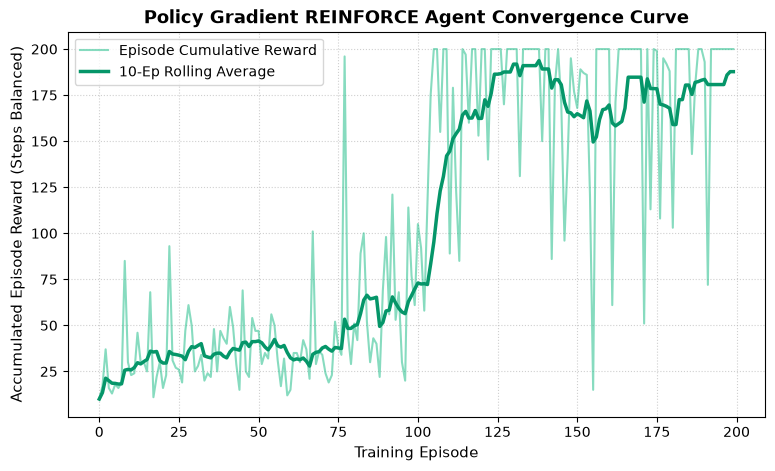

In [4]:
plt.figure(figsize=(9, 5))
plt.plot(episode_rewards, label='Episode Cumulative Reward', color='#10B981', alpha=0.5)

# Rolling average overlay
rolling_rewards = [np.mean(episode_rewards[max(0, i-10):i+1]) for i in range(len(episode_rewards))]
plt.plot(rolling_rewards, label='10-Ep Rolling Average', color='#059669', linewidth=2.5)

plt.title('Policy Gradient REINFORCE Agent Convergence Curve', fontsize=13, fontweight='bold')
plt.xlabel('Training Episode', fontsize=11)
plt.ylabel('Accumulated Episode Reward (Steps Balanced)', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
